# Portland Replication
This notebook replicates the steps used to draw the slates of viable candidates induced by the boost matrix for the 2024 elections, using the hybrid modularity score.

### Helper Functions.

In [1]:
import numpy as np
from votekit.matrices import boost_matrix
import pickle
from votekit.utils import mentions
from votekit.elections import FastSTV
from votekit.cleaning import remove_and_condense_rank_profile
from votekit.matrices import boost_matrix

def load_and_project(profile_number):
    with open(f'./data/Portland_D{profile_number}.pkl', 'rb') as f:
        loaded = pickle.load(f) #
    profile = loaded['profile']
    candidates = list(profile.candidates)

    elec=FastSTV(profile, m=3)
    mentions_dict = mentions(profile)

    viable_cands = [cand for cand in candidates if mentions_dict[cand] >= elec.threshold]
    non_viable_cands = [cand for cand in candidates if mentions_dict[cand] < elec.threshold]

    projected_profile = remove_and_condense_rank_profile(non_viable_cands, profile)
    projected_boost = boost_matrix(projected_profile, candidates = list(projected_profile.candidates))
    projected_boost = np.nan_to_num(projected_boost)

    return projected_profile, projected_boost

In [2]:
# other helpers we need to load in:
from src.scores import hybrid_modularity
from src.markov import random_partition, forward_convert, fast_short_burst, two_slate_sort_and_backwards_convert
from src.viz import viz_partition

### Replication.

Just swap out i for the district you want to run.

In [3]:
i = 1

profile, boost = load_and_project(i)
cands = list(profile.candidates)

100%|██████████| 50/50 [00:00<00:00, 1014.43it/s]


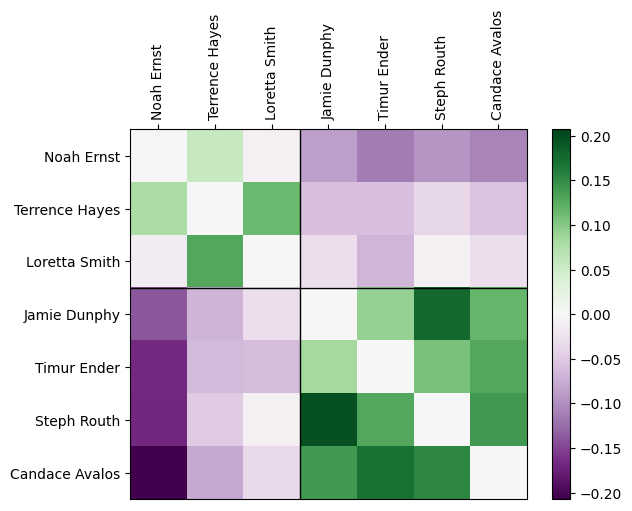

In [4]:
partition2 = forward_convert(random_partition(cands, 2), cands)
partition3 = 2*np.ones(len(cands)) # in case you want to try a 3-slate profile
hybrid_score = projected_hybrid_score = hybrid_modularity(boost, "Boost", partition2)
best_burst = fast_short_burst(partition2, projected_hybrid_score)
viz_partition(best_burst, boost, cands, centered=True)

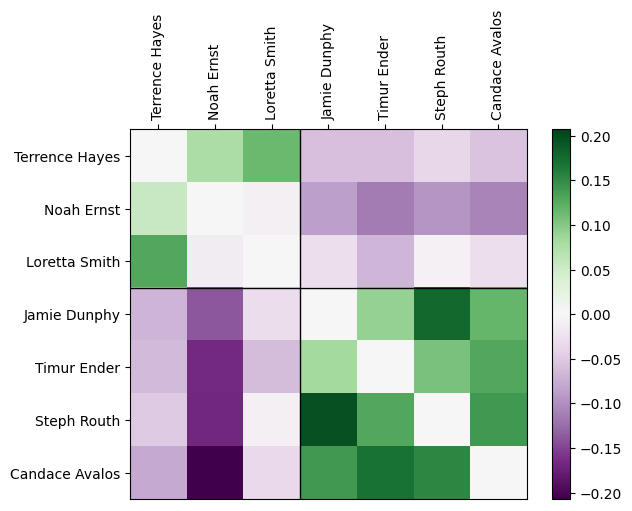

In [5]:
# if you care about ordering within slates:
final_partition = two_slate_sort_and_backwards_convert(best_burst, projected_hybrid_score, cands)
viz_partition(final_partition, boost, cands, centered=True)

### Other Miscellania.

This is an order-sensitive score for backwards-converted partitions.

In [6]:
def ordered_score_generator(score, candidates):
    # note this score is terribly slow and should never be used in chains
    def ordered_score(backwards_partition):
        if len(backwards_partition) != 2:
            raise ValueError("This function only supports two slates for now.")
        forward_partition = forward_convert(backwards_partition, candidates)
        big_score = score(forward_partition)
        overall_score = 0
        for i, bloc in enumerate(backwards_partition):
            bloc_len = len(bloc)
            for j, cand in enumerate(bloc):
                trial_step = forward_partition.copy()
                idx = candidates.index(cand)
                trial_step[idx] = 1 - trial_step[idx]
                difference = big_score - score(trial_step) # expect the big score to be more negative, so the difference is negative; the smaller the difference, the better
                if i == 1:
                    overall_score += (j + 1) * difference
                else:
                    overall_score += (bloc_len - j) * difference
        return overall_score
    return ordered_score

The partitions Moon wanted me to plot/have a look at:

In [7]:

D1_proposed = [['Candace Avalos', 'Steph Routh', 'Jamie Dunphy', 'Timur Ender'], 
               ['Loretta Smith', 'Noah Ernst','Terrence Hayes']]
D2_proposed = [['Tiffani Penson', 'Dan Ryan', 'Elana Pirtle-Guiney', 'Mariah Hudson'], 
               ['Michelle DePass', 'Sameer Kanal', 'Nat West','Jonathan Tasini','Marnie Glickman']]
D3_proposed = [['Angelita Morillo', 'Tiffany Koyama Lane',], 
               ['Steve Novick', 'Jesse Cornett', 'Rex Burkholder']]
D4_proposed = [['Olivia Clark', 'Eric Zimmerman', 'Eli Arnold', 'Bob Weinstein'],
               ['Mitch Green', 'Sarah Silkie', 'Chad Lykins', 'Lisa Freeman']]

If you want to find the ranking of a proposed partition amid all possible partitions, just make sure the final partition has the right slate first/second (the commented block can flip it):

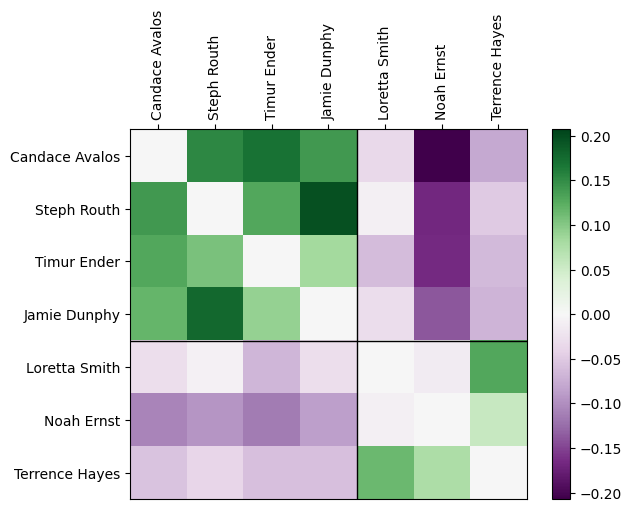

In [ ]:
flipped_optimum = 1-best_burst
final_partition = two_slate_sort_and_backwards_convert(flipped_optimum, projected_hybrid_score, cands)
viz_partition(final_partition, boost, cands, centered=True)

In [9]:
import itertools

ordered_score = ordered_score_generator(projected_hybrid_score, cands)
proposed_partition = D1_proposed 

all_possible_ordered_scores = []
all_possible_slates = []
for perm in itertools.permutations(final_partition[0]):
    for perm2 in itertools.permutations(final_partition[1]):
        test_partition = [list(perm), list(perm2)]
        all_possible_ordered_scores.append(ordered_score(test_partition))
        all_possible_slates.append(test_partition)

zipped = list(zip(all_possible_ordered_scores, all_possible_slates))
zipped.sort(reverse=False) # more negative is better
all_possible_ordered_scores, all_possible_slates = zip(*zipped)

# find the index of the original sorted_slate and moon_partition
original_sorted_index = all_possible_slates.index(final_partition)
moon_partition_index = all_possible_slates.index(proposed_partition)

print(len(all_possible_slates))
print(original_sorted_index)
print(moon_partition_index)

144
0
2


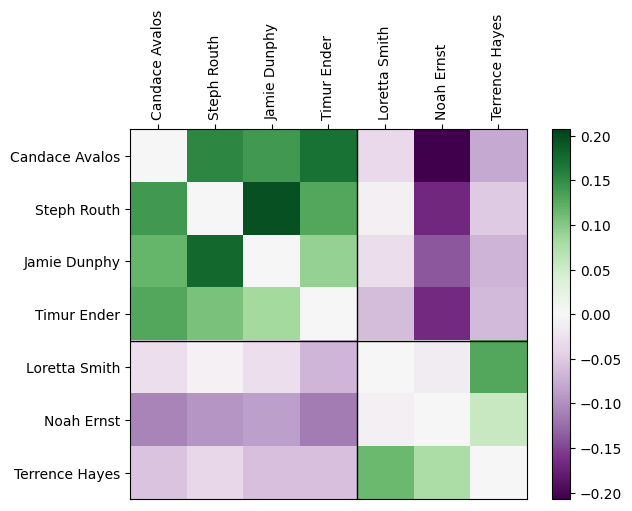

In [10]:
viz_partition(proposed_partition, boost, cands, centered=True)